In [5]:
import pandas as pd
import seaborn as sns

# Cargamos un dataset de ejemplo que viene incluido en seaborn
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# ¿Cuántas filas y columnas tiene?
print(tips.shape)

# Información general: tipos de datos, si hay nulos
tips.info()

# Estadísticas básicas de las columnas numéricas
tips.describe()

(244, 7)
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [8]:
tips.groupby('time')['tip'].mean()

time
Lunch     2.728088
Dinner    3.102670
Name: tip, dtype: float64

In [10]:
tips.groupby('time')['total_bill'].mean()

time
Lunch     17.168676
Dinner    20.797159
Name: total_bill, dtype: float64

In [12]:
tips['tip_pct'] = tips['tip'] / tips['total_bill'] * 100
tips.groupby('time')['tip_pct'].mean()

time
Lunch     16.412793
Dinner    15.951779
Name: tip_pct, dtype: float64

In [14]:
tips.groupby('size')['tip_pct'].mean()

size
1    21.729202
2    16.571919
3    15.215685
4    14.594901
5    14.149549
6    15.622920
Name: tip_pct, dtype: float64

In [15]:
tips['size'].value_counts().sort_index()

size
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64

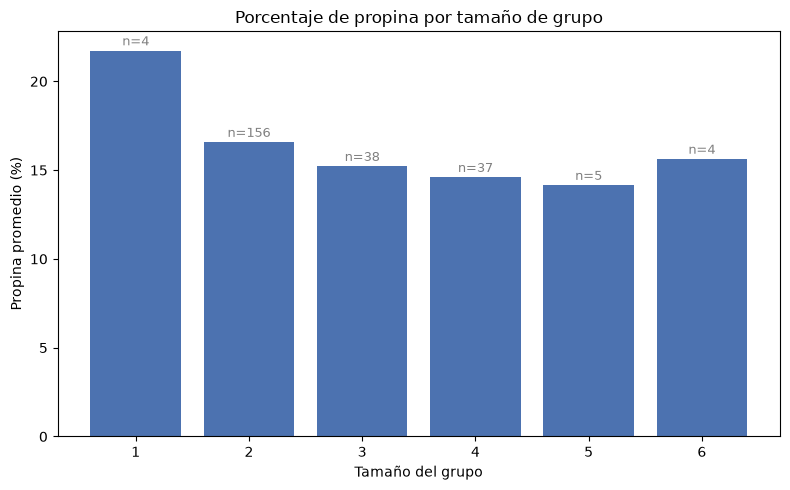

In [16]:
import matplotlib.pyplot as plt

# Calculamos el promedio de propina y el conteo por tamaño de grupo
promedio_por_size = tips.groupby('size')['tip_pct'].mean()
conteo_por_size = tips['size'].value_counts().sort_index()

# Creamos la gráfica
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(promedio_por_size.index, promedio_por_size.values, color='#4C72B0')

# Agregamos el número de muestras (n) arriba de cada barra
for i, size in enumerate(promedio_por_size.index):
    n = conteo_por_size[size]
    altura = promedio_por_size.values[i]
    ax.text(size, altura + 0.3, f'n={n}', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Tamaño del grupo')
ax.set_ylabel('Propina promedio (%)')
ax.set_title('Porcentaje de propina por tamaño de grupo')
ax.set_xticks(promedio_por_size.index)

plt.tight_layout()
plt.show()